# Download Chinese Traffic Signs Dataset

This notebook downloads the **Chinese Traffic Signs** dataset from Kaggle:

`dmitryyemelyanov/chinese-traffic-signs`

It saves a local copy under:

```text
../data/chinese_traffic_signs/
```

Recommended project structure:

```text
project/
├── data/
│   └── chinese_traffic_signs/
└── notebooks/
    ├── 01_download_chinese_traffic_signs.ipynb
    ├── 02_remove_input_duplicates_from_training_dataset.ipynb
    └── 03_hog_features_chinese.ipynb
```

Run this notebook **once** before running the HOG feature-extraction notebook.

## 2. Import Libraries and Set Local Paths

In [1]:
from pathlib import Path
import shutil
import os
import pandas as pd
import kagglehub

# Dataset identifier on Kaggle
DATASET_HANDLE = "dmitryyemelyanov/chinese-traffic-signs"

# This matches the relative project structure used by the HOG notebook.
DATA_DIR = Path("../data")
DATASET_DIR = DATA_DIR / "chinese_traffic_signs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

print("Data root:")
print(DATA_DIR.resolve())

print("\nChinese Traffic Signs local folder:")
print(DATASET_DIR.resolve())


Data root:
/home/hongye/projects/traffic-sign-recognition/data

Chinese Traffic Signs local folder:
/home/hongye/projects/traffic-sign-recognition/data/chinese_traffic_signs


/home/hongye/projects/traffic-sign-recognition/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Download the Dataset

KaggleHub first downloads the dataset to its cache.  
The next cell then copies the files into the project's local `../data/chinese_traffic_signs/` folder.

If the local folder already contains the dataset, the copy step is skipped to avoid unnecessary duplication.


In [2]:
# Download the dataset from Kaggle
downloaded_path = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
)

print("KaggleHub download/cache location:")
print(downloaded_path.resolve())

# Check whether our local project dataset folder already has files
existing_files = [p for p in DATASET_DIR.rglob("*") if p.is_file()]

if existing_files:
    print(
        f"\nLocal dataset already exists "
        f"({len(existing_files)} files found)."
    )
    print("Copy step skipped.")
else:
    print("\nCopying dataset into the local project data folder...")

    for item in downloaded_path.iterdir():
        destination = DATASET_DIR / item.name

        if item.is_dir():
            shutil.copytree(
                item,
                destination,
                dirs_exist_ok=True
            )
        else:
            shutil.copy2(
                item,
                destination
            )

    print("Copy completed.")

print("\nFinal local dataset path:")
print(DATASET_DIR.resolve())


KaggleHub download/cache location:
/home/hongye/.cache/kagglehub/datasets/dmitryyemelyanov/chinese-traffic-signs/versions/2

Copying dataset into the local project data folder...


Copy completed.

Final local dataset path:
/home/hongye/projects/traffic-sign-recognition/data/chinese_traffic_signs


## 4. Verify the Download

This cell displays the downloaded directory structure and counts the image files.


In [3]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".ppm"
}

all_files = [
    p for p in DATASET_DIR.rglob("*")
    if p.is_file()
]

image_files = [
    p for p in all_files
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

csv_files = [
    p for p in all_files
    if p.suffix.lower() == ".csv"
]

print("Dataset path:")
print(DATASET_DIR.resolve())

print("\nTotal files:", len(all_files))
print("Image files:", len(image_files))
print("CSV files:", len(csv_files))

print("\nTop-level contents:")
for p in sorted(DATASET_DIR.iterdir()):
    item_type = "DIR " if p.is_dir() else "FILE"
    print(f"{item_type}: {p.name}")


Dataset path:
/home/hongye/projects/traffic-sign-recognition/data/chinese_traffic_signs

Total files: 5999
Image files: 5998
CSV files: 1

Top-level contents:
FILE: annotations.csv
DIR : images


## 5. Inspect `annotations.csv`

The Kaggle dataset is commonly distributed with an `annotations.csv` file containing image annotations and class/category information.

This cell searches for the CSV automatically and displays its columns and first few rows.


In [4]:
annotation_candidates = [
    p for p in csv_files
    if "annotation" in p.name.lower()
]

if annotation_candidates:
    ANNOTATIONS_FILE = annotation_candidates[0]

    print("Annotations file:")
    print(ANNOTATIONS_FILE.resolve())

    annotations_df = pd.read_csv(
        ANNOTATIONS_FILE
    )

    print("\nShape:", annotations_df.shape)
    print("\nColumns:")
    print(list(annotations_df.columns))

    print("\nFirst 5 rows:")
    display(annotations_df.head())
else:
    ANNOTATIONS_FILE = None
    annotations_df = None

    print(
        "No annotations.csv file was found automatically."
    )
    print(
        "Check the directory listing above to identify "
        "the dataset's metadata file."
    )


Annotations file:
/home/hongye/projects/traffic-sign-recognition/data/chinese_traffic_signs/annotations.csv

Shape: (6164, 8)

Columns:
['file_name', 'width', 'height', 'x1', 'y1', 'x2', 'y2', 'category']

First 5 rows:


,file_name,width,height,x1,y1,x2,y2,category
0,000_0001.png,134,128,19,7,120,117,0
1,000_0002.png,165,151,23,12,149,138,0
2,000_0003.png,128,122,22,14,116,105,0
3,000_0010.png,80,73,14,8,67,63,0
4,000_0011.png,186,174,36,15,155,157,0


## 6. Show a Few Downloaded Image Paths

In [5]:
print("First 10 image files:")

for image_path in image_files[:10]:
    print(image_path)


First 10 image files:
../data/chinese_traffic_signs/images/027_1_0004.png
../data/chinese_traffic_signs/images/007_1_0050.png
../data/chinese_traffic_signs/images/004_0010_j.png
../data/chinese_traffic_signs/images/054_0131.png
../data/chinese_traffic_signs/images/030_1_0058.png
../data/chinese_traffic_signs/images/053_0001.png
../data/chinese_traffic_signs/images/030_1_0015.png
../data/chinese_traffic_signs/images/003_0107.png
../data/chinese_traffic_signs/images/007_0019.png
../data/chinese_traffic_signs/images/042_0003.png


## 7. Optional: Display Sample Images

This is only a quick check that the downloaded images can be opened correctly.


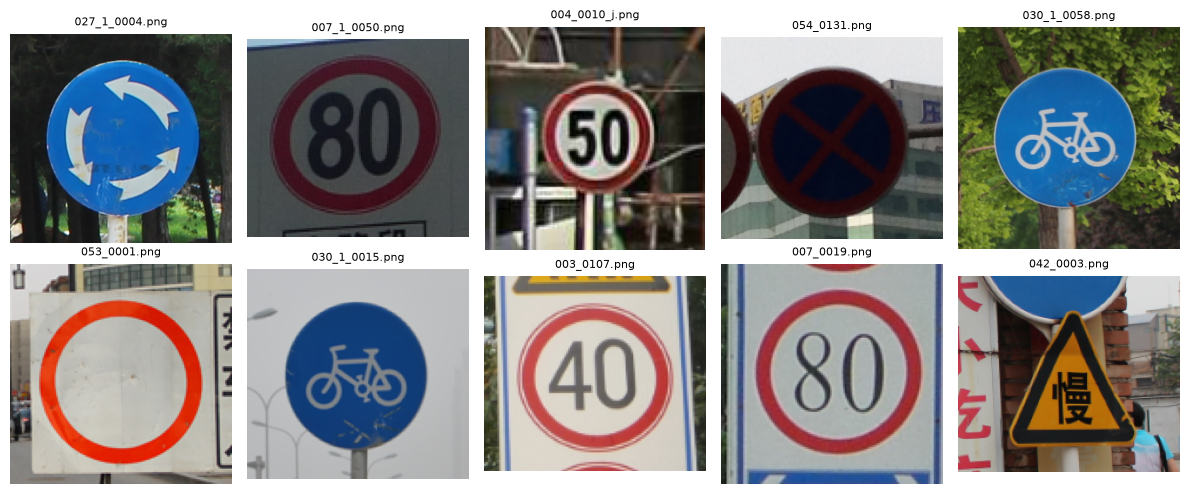

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

sample_images = image_files[:10]

if len(sample_images) == 0:
    print("No image files found.")
else:
    fig, axes = plt.subplots(
        2,
        5,
        figsize=(12, 5)
    )

    axes = axes.flatten()

    for ax, image_path in zip(
        axes,
        sample_images
    ):
        image = Image.open(
            image_path
        ).convert("RGB")

        ax.imshow(image)
        ax.set_title(
            image_path.name,
            fontsize=8
        )
        ax.axis("off")

    for ax in axes[len(sample_images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 8. Paths to Use in the HOG Notebook

After this notebook finishes, the useful paths are:

```python
from pathlib import Path

DATA_DIR = Path("../data")
CHINESE_DATASET_DIR = DATA_DIR / "chinese_traffic_signs"
```

Next steps: run `02_remove_input_duplicates_from_training_dataset.ipynb`, then `03_hog_features_chinese.ipynb`.